# Machine Learning Customer Segmentation

## Customer Intelligence Analytics

This notebook applies unsupervised machine learning to discover natural
customer groups directly from behavioral data.

Unlike the previous RFM segmentation, customer labels are not predefined.

### Objectives

- Engineer behavioral customer features.
- Prepare skewed features for distance-based clustering.
- Standardize features before K-Means.
- Compare multiple values of K.
- Evaluate cluster quality using several metrics.
- Select a defensible number of customer clusters.
- Profile and interpret the discovered clusters.
- Compare machine-learning clusters with RFM business segments.

In [53]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)


pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")


RANDOM_STATE = 42


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent


RFM_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "rfm_customer_segments.parquet"
)

CUSTOMER_TRANSACTIONS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_transactions.parquet"
)

FEATURE_OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "ml_segmentation_features.parquet"
)

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


print(f"RFM data:          {RFM_PATH}")
print(f"Customer activity: {CUSTOMER_TRANSACTIONS_PATH}")

RFM data:          c:\Users\omary\Documents\VS Code\customer-intelligence-analytics\data\processed\rfm_customer_segments.parquet
Customer activity: c:\Users\omary\Documents\VS Code\customer-intelligence-analytics\data\processed\customer_transactions.parquet


In [54]:
rfm = pd.read_parquet(RFM_PATH)

customer_transactions = pd.read_parquet(
    CUSTOMER_TRANSACTIONS_PATH
)


customer_transactions["invoice_key"] = (
    customer_transactions["source_period"].astype("string")
    + "::"
    + customer_transactions["invoice"].astype("string")
)


print(f"RFM customers:              {len(rfm):,}")

print(
    "Customer transaction rows: "
    f"{len(customer_transactions):,}"
)

print(
    "Customers in activity data: "
    f"{customer_transactions['customer_id'].nunique():,}"
)

RFM customers:              5,878
Customer transaction rows: 812,368
Customers in activity data: 5,942


In [55]:
invoice_activity = (
    customer_transactions
    .groupby(
        [
            "customer_id",
            "invoice_key",
        ],
        observed=True,
    )
    .agg(
        invoice_date=("invoice_date", "min"),
        is_return_invoice=("is_return_or_reversal", "max"),
    )
    .reset_index()
)


return_behavior = (
    invoice_activity
    .groupby(
        "customer_id",
        observed=True,
    )
    .agg(
        total_activity_invoices=("invoice_key", "nunique"),
        return_invoices=("is_return_invoice", "sum"),
    )
    .reset_index()
)


return_behavior["return_invoice_rate"] = (
    return_behavior["return_invoices"]
    / return_behavior["total_activity_invoices"]
)


display(return_behavior.head())

,customer_id,total_activity_invoices,return_invoices,return_invoice_rate
0,12346,17,5,0.294
1,12347,9,0,0.000
2,12348,5,0,0.000
3,12349,5,1,0.200
4,12350,1,0,0.000


In [56]:
customer_features = rfm.merge(
    return_behavior,
    on="customer_id",
    how="left",
    validate="one_to_one",
)


customer_features[
    [
        "total_activity_invoices",
        "return_invoices",
        "return_invoice_rate",
    ]
] = customer_features[
    [
        "total_activity_invoices",
        "return_invoices",
        "return_invoice_rate",
    ]
].fillna(0)


print(
    f"Customers after merge: "
    f"{len(customer_features):,}"
)

display(customer_features.head())

Customers after merge: 5,878


,customer_id,first_purchase,last_purchase,frequency,monetary,total_units,unique_products,recency,tenure_days,average_order_value,r_score,f_score,m_score,rfm_total_score,rfm_code,segment,value_tier,recommended_action,total_activity_invoices,return_invoices,return_invoice_rate
0,12346,2009-12-14 08:34:00,2011-01-18 10:01:00,12,"77,556.460",74285,27,326,400,"6,463.038",2,5,5,12,255,Cannot Lose Them,High Value,High-priority retention intervention; consider...,17,5,0.294
1,12347,2010-10-31 14:20:00,2011-12-07 15:52:00,9,"5,633.320",3286,126,2,402,625.924,5,5,5,15,555,Champions,High Value,"Reward with VIP benefits, early access, referr...",9,0,0.000
2,12348,2010-09-27 14:59:00,2011-09-25 13:13:00,5,"2,019.400",2714,25,75,362,403.880,3,4,4,11,344,Loyal Customers,High Value,Strengthen loyalty through personalized offers...,5,0,0.000
3,12349,2010-04-29 13:20:00,2011-11-21 09:51:00,4,"4,428.690",1624,138,19,570,"1,107.172",5,3,5,13,535,Loyal Customers,High Value,Strengthen loyalty through personalized offers...,5,1,0.200
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.400,197,17,310,0,334.400,2,1,2,5,212,About to Sleep,Low Value,Trigger low-cost reactivation campaigns.,1,0,0.000


## Features used for clustering

The clustering model uses six behavioral dimensions:

- **Recency:** days since the customer's last purchase.
- **Frequency:** number of distinct sales invoices.
- **Monetary:** total positive purchase value.
- **Unique products:** breadth of product engagement.
- **Tenure:** time between first and most recent purchases.
- **Return invoice rate:** proportion of customer activity invoices associated
  with returns or reversals.

RFM scores and the predefined RFM segment are deliberately excluded from the
clustering inputs because the objective is to discover customer structure
independently of the rule-based segmentation.

Average order value is retained for later profiling but excluded from the
clustering feature set because it is mathematically derived from Monetary and
Frequency and would add redundant weighting.

In [57]:
MODEL_FEATURES = [
    "recency",
    "frequency",
    "monetary",
    "unique_products",
    "tenure_days",
    "return_invoice_rate",
]


X_raw = customer_features[
    MODEL_FEATURES
].copy()


display(X_raw.head())

,recency,frequency,monetary,unique_products,tenure_days,return_invoice_rate
0,326,12,"77,556.460",27,400,0.294
1,2,9,"5,633.320",126,402,0.000
2,75,5,"2,019.400",25,362,0.000
3,19,4,"4,428.690",138,570,0.200
4,310,1,334.400,17,0,0.000


In [58]:
# Convert all clustering features explicitly to numeric float values.
X_raw = (
    X_raw
    .apply(pd.to_numeric, errors="raise")
    .astype("float64")
)


assert len(X_raw) == 5_878

assert not X_raw.isna().any().any()

assert np.isfinite(
    X_raw.to_numpy(dtype="float64")
).all()

assert (X_raw >= 0).all().all()


print("Clustering feature validation passed.")

display(X_raw.dtypes)

Clustering feature validation passed.


recency                float64
frequency              float64
monetary               float64
unique_products        float64
tenure_days            float64
return_invoice_rate    float64
dtype: object

In [59]:
feature_profile = (
    X_raw.describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .T
)


feature_profile["skewness"] = X_raw.skew()


display(feature_profile)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max,skewness
recency,"5,878.000",201.332,209.339,1.000,26.000,96.000,380.000,535.000,625.000,726.000,739.000,0.887
frequency,"5,878.000",6.421,13.387,1.000,1.000,3.000,7.000,14.000,21.000,46.230,406.000,12.718
monetary,"5,878.000","3,008.755","14,731.924",2.950,345.115,887.390,"2,298.005","5,557.650","9,504.783","29,710.548","608,821.650",25.337
unique_products,"5,878.000",81.989,116.485,1.000,19.000,45.000,103.000,198.000,281.000,502.690,"2,550.000",6.224
tenure_days,"5,878.000",273.022,258.808,0.000,0.000,220.500,511.000,667.000,712.000,732.000,738.000,0.389
return_invoice_rate,"5,878.000",0.117,0.166,0.000,0.000,0.000,0.222,0.375,0.500,0.600,0.800,1.268


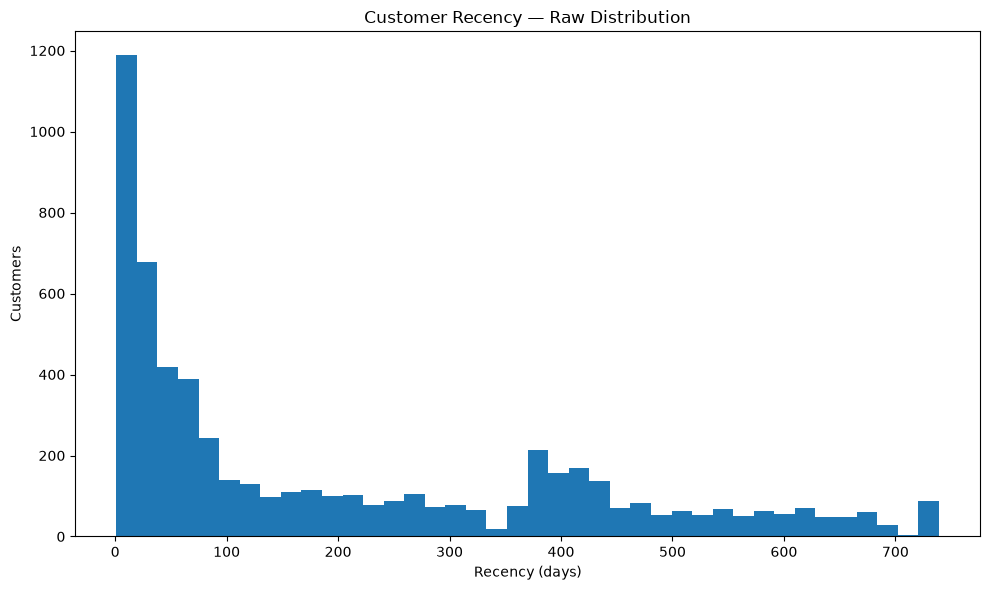

In [60]:
plt.figure(figsize=(10, 6))

plt.hist(
    X_raw["recency"],
    bins=40,
)

plt.title("Customer Recency — Raw Distribution")
plt.xlabel("Recency (days)")
plt.ylabel("Customers")
plt.tight_layout()

plt.show()

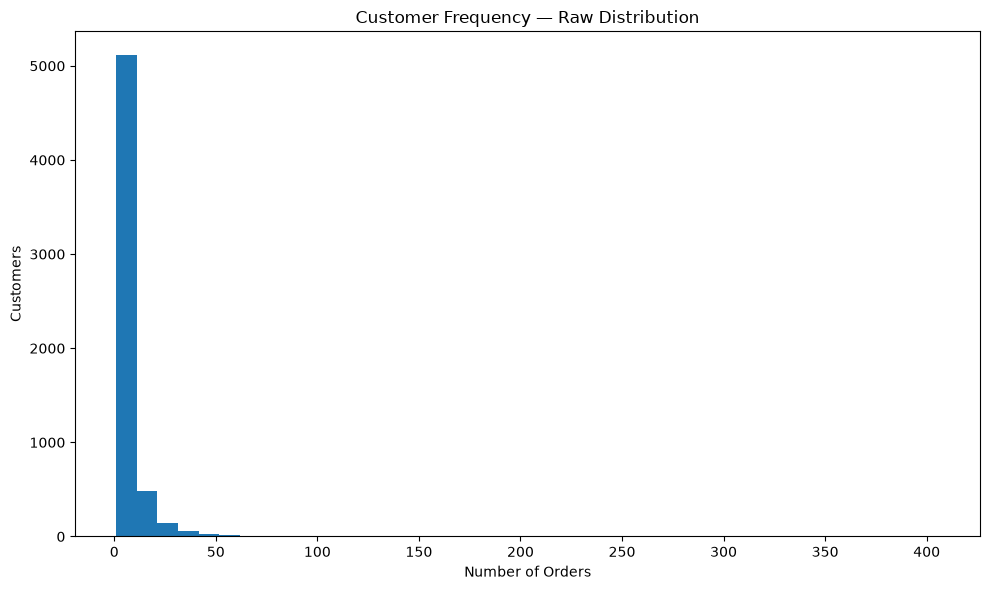

In [61]:
plt.figure(figsize=(10, 6))

plt.hist(
    X_raw["frequency"],
    bins=40,
)

plt.title("Customer Frequency — Raw Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Customers")
plt.tight_layout()

plt.show()

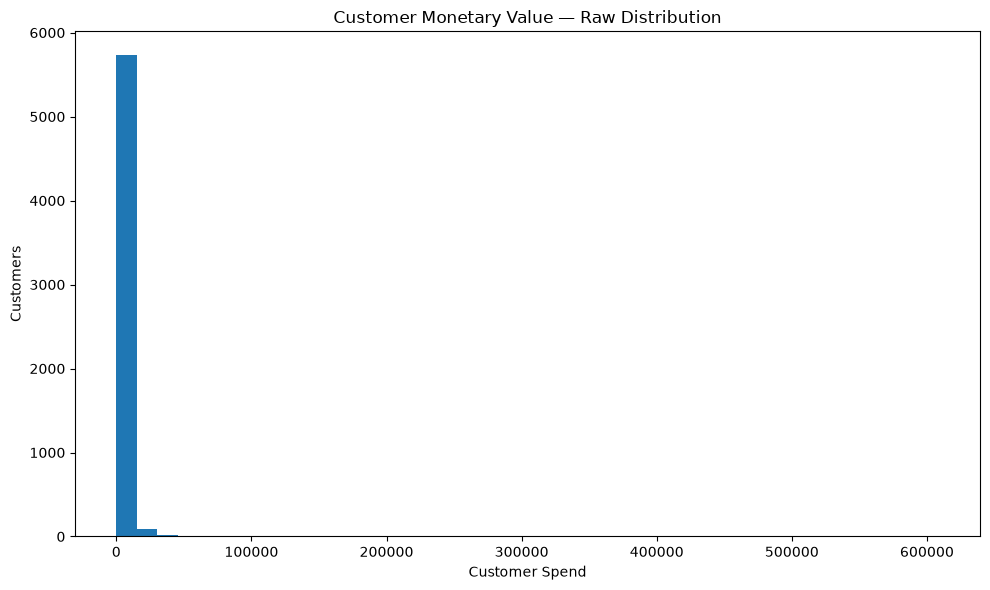

In [62]:
plt.figure(figsize=(10, 6))

plt.hist(
    X_raw["monetary"],
    bins=40,
)

plt.title("Customer Monetary Value — Raw Distribution")
plt.xlabel("Customer Spend")
plt.ylabel("Customers")
plt.tight_layout()

plt.show()

In [63]:
X_transformed = X_raw.copy()


for column in MODEL_FEATURES:
    X_transformed[column] = np.log1p(
        X_transformed[column]
    )


display(
    X_transformed.describe().T
)

,count,mean,std,min,25%,50%,75%,max
recency,"5,878.000",4.454,1.559,0.693,3.296,4.575,5.943,6.607
frequency,"5,878.000",1.561,0.816,0.693,0.693,1.386,2.079,6.009
monetary,"5,878.000",6.831,1.389,1.374,5.847,6.789,7.740,13.319
unique_products,"5,878.000",3.760,1.219,0.693,2.996,3.829,4.644,7.844
tenure_days,"5,878.000",4.003,2.688,0.000,0.000,5.400,6.238,6.605
return_invoice_rate,"5,878.000",0.101,0.138,0.000,0.000,0.000,0.201,0.588


In [64]:
skewness_comparison = pd.DataFrame(
    {
        "raw_skewness": X_raw.skew(),
        "transformed_skewness": X_transformed.skew(),
    }
)


skewness_comparison["absolute_reduction"] = (
    skewness_comparison["raw_skewness"].abs()
    - skewness_comparison[
        "transformed_skewness"
    ].abs()
)


display(skewness_comparison)

,raw_skewness,transformed_skewness,absolute_reduction
recency,0.887,-0.489,0.399
frequency,12.718,0.993,11.725
monetary,25.337,0.268,25.069
unique_products,6.224,-0.281,5.943
tenure_days,0.389,-0.673,-0.284
return_invoice_rate,1.268,1.088,0.180


In [65]:
scaler = StandardScaler()


X_scaled_array = scaler.fit_transform(
    X_transformed
)


X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=MODEL_FEATURES,
    index=customer_features.index,
)


display(X_scaled.head())

,recency,frequency,monetary,unique_products,tenure_days,return_invoice_rate
0,0.857,1.231,3.189,-0.351,0.741,1.138
1,-2.152,0.909,1.301,0.890,0.743,-0.734
2,-0.079,0.283,0.562,-0.412,0.704,-0.734
3,-0.935,0.059,1.127,0.964,0.873,0.590
4,0.825,-1.064,-0.731,-0.713,-1.489,-0.734


In [66]:
scaling_check = pd.DataFrame(
    {
        "mean": X_scaled.mean(),
        "std": X_scaled.std(ddof=0),
    }
)


display(scaling_check)

,mean,std
recency,-0.000,1.000
frequency,0.000,1.000
monetary,-0.000,1.000
unique_products,-0.000,1.000
tenure_days,-0.000,1.000
return_invoice_rate,-0.000,1.000


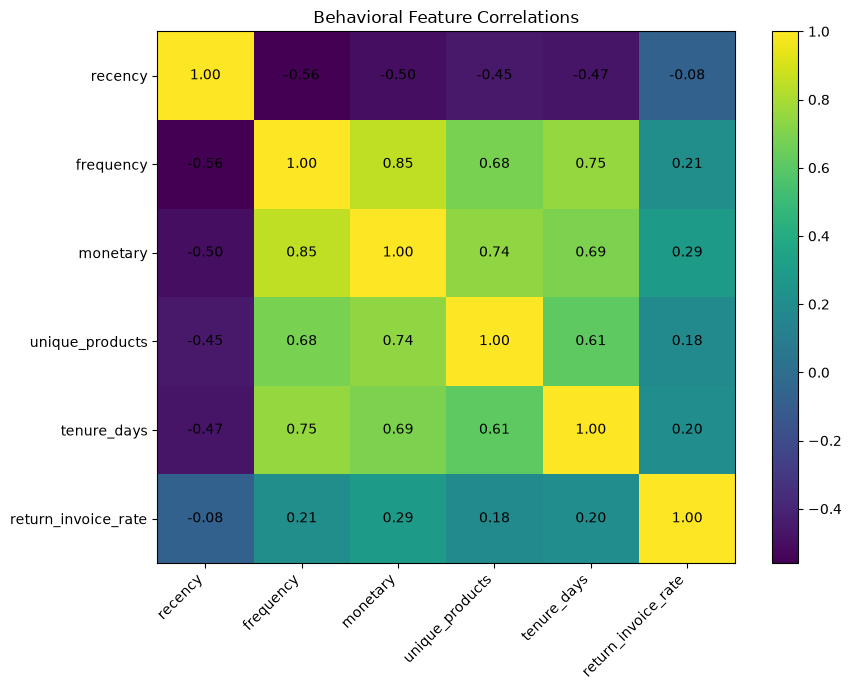

In [67]:
correlation_matrix = X_transformed.corr()


fig, ax = plt.subplots(figsize=(9, 7))

image = ax.imshow(
    correlation_matrix,
    aspect="auto",
)


ax.set_xticks(
    range(len(MODEL_FEATURES)),
    MODEL_FEATURES,
    rotation=45,
    ha="right",
)

ax.set_yticks(
    range(len(MODEL_FEATURES)),
    MODEL_FEATURES,
)


for row in range(len(MODEL_FEATURES)):
    for column in range(len(MODEL_FEATURES)):
        ax.text(
            column,
            row,
            f"{correlation_matrix.iloc[row, column]:.2f}",
            ha="center",
            va="center",
        )


plt.title("Behavioral Feature Correlations")
plt.colorbar(image)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "ml_feature_correlations.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

In [68]:
features_to_save = customer_features[
    [
        "customer_id",
        *MODEL_FEATURES,
        "average_order_value",
        "segment",
        "value_tier",
    ]
].copy()


features_to_save.to_parquet(
    FEATURE_OUTPUT_PATH,
    index=False,
)


print(
    f"Saved clustering features to: "
    f"{FEATURE_OUTPUT_PATH}"
)

Saved clustering features to: c:\Users\omary\Documents\VS Code\customer-intelligence-analytics\data\interim\ml_segmentation_features.parquet


In [69]:
clustering_results = []


for k in range(2, 9):

    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=50,
        max_iter=500,
        random_state=RANDOM_STATE,
    )

    labels = model.fit_predict(
        X_scaled
    )

    cluster_sizes = pd.Series(
        labels
    ).value_counts()

    clustering_results.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(
                X_scaled,
                labels,
            ),
            "calinski_harabasz": (
                calinski_harabasz_score(
                    X_scaled,
                    labels,
                )
            ),
            "davies_bouldin": (
                davies_bouldin_score(
                    X_scaled,
                    labels,
                )
            ),
            "smallest_cluster": int(
                cluster_sizes.min()
            ),
            "largest_cluster": int(
                cluster_sizes.max()
            ),
            "largest_cluster_share_pct": float(
                cluster_sizes.max()
                / len(labels)
                * 100
            ),
        }
    )


clustering_evaluation = pd.DataFrame(
    clustering_results
)


display(clustering_evaluation)

,k,inertia,silhouette,calinski_harabasz,davies_bouldin,smallest_cluster,largest_cluster,largest_cluster_share_pct
0,2,"20,478.057",0.356,"4,243.865",1.095,2651,3227,54.900
1,3,"16,035.539",0.292,"3,523.135",1.267,1555,2490,42.361
2,4,"13,125.831",0.322,"3,302.986",1.142,986,1848,31.439
3,5,"11,651.438",0.321,"2,976.062",1.172,326,1626,27.662
4,6,"10,483.079",0.292,"2,776.641",1.189,302,1482,25.213
5,7,"9,673.364",0.286,"2,589.007",1.202,286,1469,24.991
6,8,"8,947.720",0.249,"2,466.726",1.272,283,967,16.451


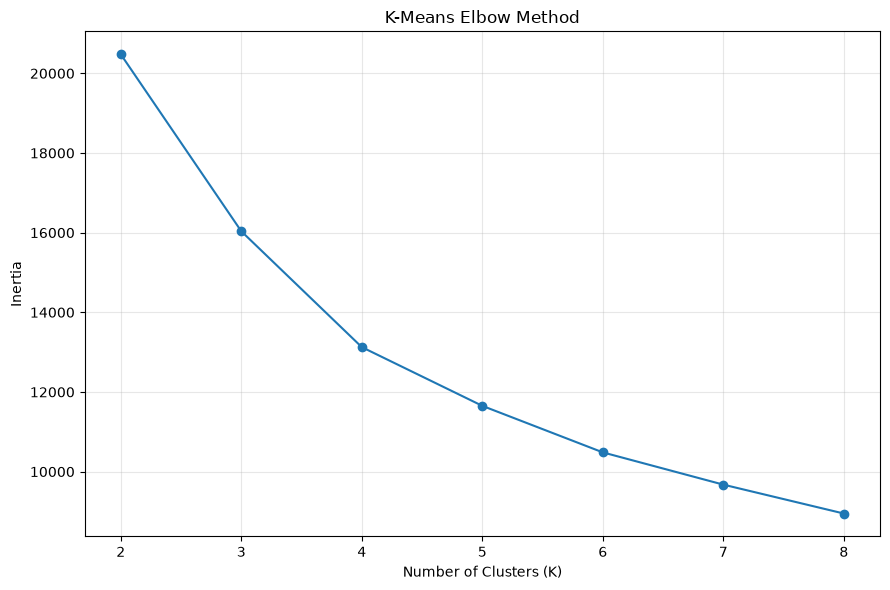

In [70]:
plt.figure(figsize=(9, 6))

plt.plot(
    clustering_evaluation["k"],
    clustering_evaluation["inertia"],
    marker="o",
)

plt.title("K-Means Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(
    clustering_evaluation["k"]
)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "kmeans_elbow_curve.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

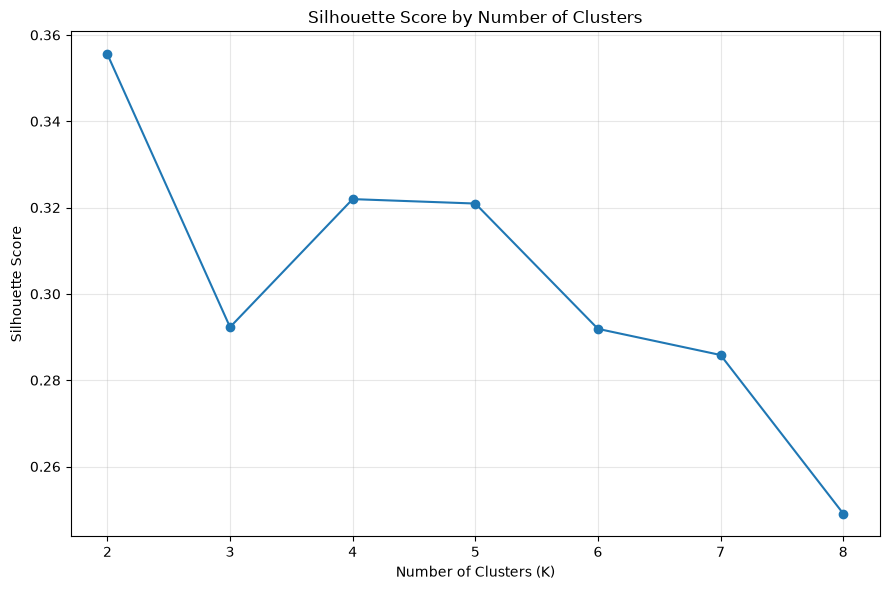

In [71]:
plt.figure(figsize=(9, 6))

plt.plot(
    clustering_evaluation["k"],
    clustering_evaluation["silhouette"],
    marker="o",
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(
    clustering_evaluation["k"]
)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "kmeans_silhouette_scores.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

In [72]:
evaluation_ranking = (
    clustering_evaluation
    .sort_values(
        [
            "silhouette",
            "davies_bouldin",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)


display(evaluation_ranking)

,k,inertia,silhouette,calinski_harabasz,davies_bouldin,smallest_cluster,largest_cluster,largest_cluster_share_pct
0,2,"20,478.057",0.356,"4,243.865",1.095,2651,3227,54.900
1,4,"13,125.831",0.322,"3,302.986",1.142,986,1848,31.439
2,5,"11,651.438",0.321,"2,976.062",1.172,326,1626,27.662
3,3,"16,035.539",0.292,"3,523.135",1.267,1555,2490,42.361
4,6,"10,483.079",0.292,"2,776.641",1.189,302,1482,25.213
5,7,"9,673.364",0.286,"2,589.007",1.202,286,1469,24.991
6,8,"8,947.720",0.249,"2,466.726",1.272,283,967,16.451


## Selecting the Final Number of Clusters

Multiple K-Means solutions from K=2 to K=8 were evaluated using inertia,
Silhouette Score, Calinski-Harabasz Score, Davies-Bouldin Score, and cluster
size balance.

K=2 achieved the strongest numerical separation, with the highest Silhouette
Score and lowest Davies-Bouldin Score. However, a two-cluster solution would
provide only a very broad customer split and would have limited usefulness for
customer targeting and differentiated business strategies.

K=4 was therefore selected as the final solution.

It retains a relatively strong Silhouette Score (0.322), has a favorable
Davies-Bouldin Score (1.142), and produces four reasonably balanced customer
groups, with the smallest cluster containing 986 customers and the largest
containing 1,848 customers.

K=5 produced almost no improvement in Silhouette Score while introducing a
much smaller cluster. Therefore, K=4 provides a better balance between
statistical quality, interpretability, and business usefulness.

In [73]:
BEST_K = 4

final_kmeans = KMeans(
    n_clusters=BEST_K,
    init="k-means++",
    n_init=50,
    max_iter=500,
    random_state=RANDOM_STATE,
)

customer_features["ml_cluster"] = (
    final_kmeans.fit_predict(X_scaled)
)


print("Final K-Means model trained successfully.")

display(
    customer_features["ml_cluster"]
    .value_counts()
    .sort_index()
    .to_frame("customers")
)

Final K-Means model trained successfully.


,customers
ml_cluster,
0,986
1,1455
2,1848
3,1589


In [74]:
cluster_profile = (
    customer_features
    .groupby(
        "ml_cluster",
        observed=True,
    )
    .agg(
        customers=("customer_id", "count"),
        average_recency=("recency", "mean"),
        median_recency=("recency", "median"),
        average_frequency=("frequency", "mean"),
        median_frequency=("frequency", "median"),
        average_monetary=("monetary", "mean"),
        median_monetary=("monetary", "median"),
        average_unique_products=("unique_products", "mean"),
        average_tenure_days=("tenure_days", "mean"),
        average_order_value=("average_order_value", "mean"),
        average_return_rate=("return_invoice_rate", "mean"),
    )
    .reset_index()
)


cluster_profile["customer_share_pct"] = (
    cluster_profile["customers"]
    / cluster_profile["customers"].sum()
    * 100
)


cluster_revenue = (
    customer_features
    .groupby(
        "ml_cluster",
        observed=True,
    )["monetary"]
    .sum()
)


cluster_profile["revenue"] = (
    cluster_profile["ml_cluster"]
    .map(cluster_revenue)
)


cluster_profile["revenue_share_pct"] = (
    cluster_profile["revenue"]
    / cluster_profile["revenue"].sum()
    * 100
)


display(
    cluster_profile.sort_values(
        "average_monetary",
        ascending=False,
    )
)

,ml_cluster,customers,average_recency,median_recency,average_frequency,median_frequency,average_monetary,median_monetary,average_unique_products,average_tenure_days,average_order_value,average_return_rate,customer_share_pct,revenue,revenue_share_pct
1,1,1455,40.900,19.000,17.555,12.000,"9,485.616","4,387.640",199.614,561.416,534.909,0.174,24.753,"13,801,571.081",78.039
0,0,986,264.903,236.000,2.930,3.000,"1,219.862",830.410,44.312,198.304,450.679,0.394,16.774,"1,202,783.492",6.801
2,2,1848,161.038,88.500,4.054,4.000,"1,172.248",914.440,62.751,315.873,306.731,0.024,31.439,"2,166,314.313",12.249
3,3,1589,355.649,388.000,1.147,1.000,323.972,221.530,20.037,5.478,297.663,0.002,27.033,"514,791.752",2.911


In [75]:
cluster_names = {
    0: "At-Risk Return-Heavy Customers",
    1: "High-Value Loyal Customers",
    2: "Established Moderate-Value Customers",
    3: "Dormant One-Time Customers",
}


customer_features["cluster_name"] = (
    customer_features["ml_cluster"]
    .map(cluster_names)
)


assert customer_features["cluster_name"].notna().all()


display(
    customer_features[
        [
            "customer_id",
            "ml_cluster",
            "cluster_name",
            "recency",
            "frequency",
            "monetary",
            "return_invoice_rate",
        ]
    ].head(20)
)

,customer_id,ml_cluster,cluster_name,recency,frequency,monetary,return_invoice_rate
0,12346,1,High-Value Loyal Customers,326,12,"77,556.460",0.294
1,12347,1,High-Value Loyal Customers,2,9,"5,633.320",0.000
2,12348,2,Established Moderate-Value Customers,75,5,"2,019.400",0.000
3,12349,1,High-Value Loyal Customers,19,4,"4,428.690",0.200
4,12350,3,Dormant One-Time Customers,310,1,334.400,0.000
5,12351,3,Dormant One-Time Customers,375,1,300.930,0.000
6,12352,1,High-Value Loyal Customers,36,10,"2,849.840",0.231
7,12353,2,Established Moderate-Value Customers,204,2,406.760,0.000
8,12354,3,Dormant One-Time Customers,232,1,"1,079.400",0.000
9,12355,2,Established Moderate-Value Customers,214,2,947.610,0.000


In [76]:
cluster_actions = {
    "High-Value Loyal Customers": (
        "Protect and reward through VIP benefits, personalized offers, "
        "early access, loyalty rewards, and proactive service."
    ),

    "At-Risk Return-Heavy Customers": (
        "Investigate return causes and service issues before applying "
        "targeted retention incentives."
    ),

    "Established Moderate-Value Customers": (
        "Increase purchase frequency through cross-selling, personalized "
        "recommendations, and loyalty incentives."
    ),

    "Dormant One-Time Customers": (
        "Use low-cost automated win-back campaigns and avoid expensive "
        "retention offers unless future value justifies them."
    ),
}


customer_features["cluster_action"] = (
    customer_features["cluster_name"]
    .map(cluster_actions)
)

In [77]:
cluster_business_summary = (
    customer_features
    .groupby(
        [
            "ml_cluster",
            "cluster_name",
        ],
        observed=True,
    )
    .agg(
        customers=("customer_id", "count"),
        revenue=("monetary", "sum"),
        average_recency=("recency", "mean"),
        median_recency=("recency", "median"),
        average_frequency=("frequency", "mean"),
        median_frequency=("frequency", "median"),
        average_monetary=("monetary", "mean"),
        median_monetary=("monetary", "median"),
        average_unique_products=("unique_products", "mean"),
        average_tenure_days=("tenure_days", "mean"),
        average_order_value=("average_order_value", "mean"),
        average_return_rate=("return_invoice_rate", "mean"),
    )
    .reset_index()
)


cluster_business_summary["customer_share_pct"] = (
    cluster_business_summary["customers"]
    / cluster_business_summary["customers"].sum()
    * 100
)


cluster_business_summary["revenue_share_pct"] = (
    cluster_business_summary["revenue"]
    / cluster_business_summary["revenue"].sum()
    * 100
)


display(
    cluster_business_summary.sort_values(
        "revenue",
        ascending=False,
    )
)

,ml_cluster,cluster_name,customers,revenue,average_recency,median_recency,average_frequency,median_frequency,average_monetary,median_monetary,average_unique_products,average_tenure_days,average_order_value,average_return_rate,customer_share_pct,revenue_share_pct
1,1,High-Value Loyal Customers,1455,"13,801,571.081",40.900,19.000,17.555,12.000,"9,485.616","4,387.640",199.614,561.416,534.909,0.174,24.753,78.039
2,2,Established Moderate-Value Customers,1848,"2,166,314.313",161.038,88.500,4.054,4.000,"1,172.248",914.440,62.751,315.873,306.731,0.024,31.439,12.249
0,0,At-Risk Return-Heavy Customers,986,"1,202,783.492",264.903,236.000,2.930,3.000,"1,219.862",830.410,44.312,198.304,450.679,0.394,16.774,6.801
3,3,Dormant One-Time Customers,1589,"514,791.752",355.649,388.000,1.147,1.000,323.972,221.530,20.037,5.478,297.663,0.002,27.033,2.911


In [78]:
pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE,
)


pca_coordinates = pca.fit_transform(
    X_scaled
)


customer_features["pca_1"] = pca_coordinates[:, 0]
customer_features["pca_2"] = pca_coordinates[:, 1]


print(
    "Explained variance by PC1: "
    f"{pca.explained_variance_ratio_[0] * 100:.2f}%"
)

print(
    "Explained variance by PC2: "
    f"{pca.explained_variance_ratio_[1] * 100:.2f}%"
)

print(
    "Total variance represented: "
    f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
)

Explained variance by PC1: 60.59%
Explained variance by PC2: 15.91%
Total variance represented: 76.49%


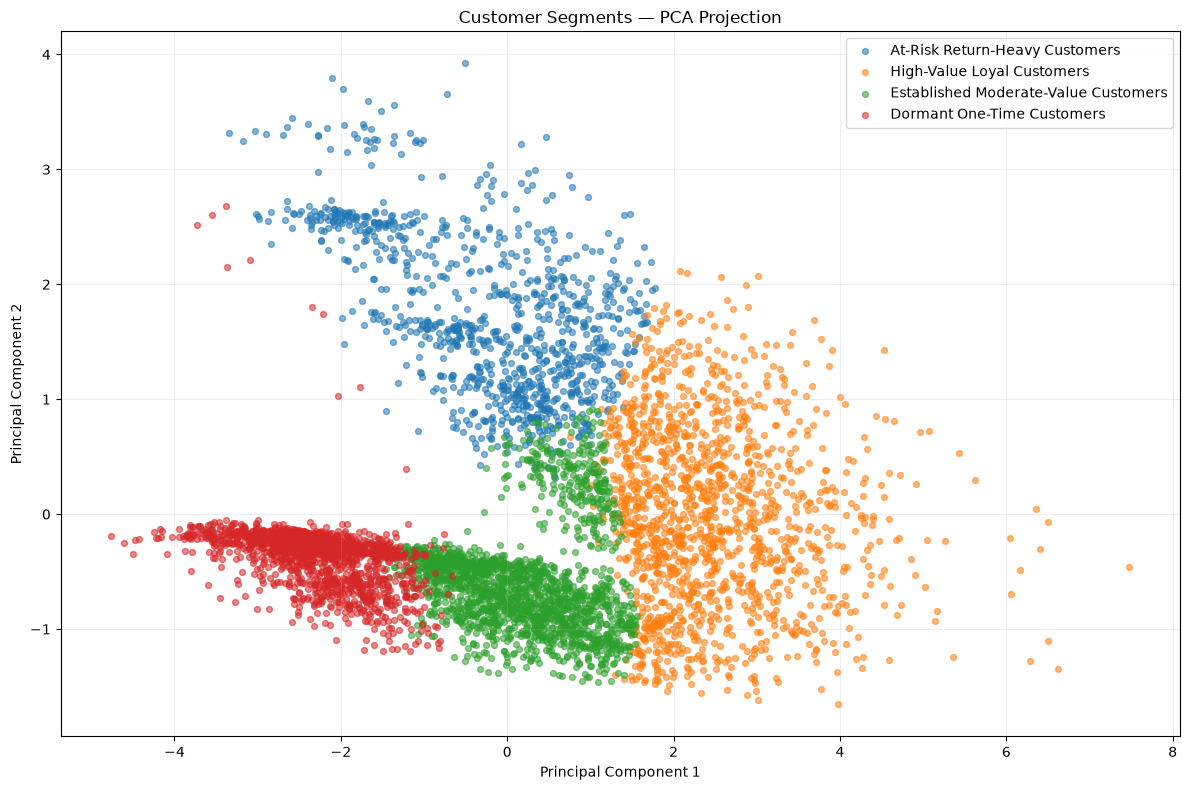

In [79]:
plt.figure(figsize=(12, 8))


for cluster_id in sorted(
    customer_features["ml_cluster"].unique()
):

    cluster_data = customer_features.loc[
        customer_features["ml_cluster"]
        == cluster_id
    ]

    cluster_name = cluster_names[
        cluster_id
    ]

    plt.scatter(
        cluster_data["pca_1"],
        cluster_data["pca_2"],
        s=18,
        alpha=0.55,
        label=cluster_name,
    )


plt.title(
    "Customer Segments — PCA Projection"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "ml_customer_clusters_pca.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

In [80]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=MODEL_FEATURES,
    columns=[
        "PC1",
        "PC2",
    ],
)


display(pca_loadings)

,PC1,PC2
recency,-0.352,0.296
frequency,0.483,-0.064
monetary,0.480,0.045
unique_products,0.435,-0.059
tenure_days,0.442,-0.043
return_invoice_rate,0.167,0.949


In [81]:
rfm_ml_comparison = pd.crosstab(
    customer_features["segment"],
    customer_features["cluster_name"],
    margins=True,
)


display(rfm_ml_comparison)

cluster_name,At-Risk Return-Heavy Customers,Dormant One-Time Customers,Established Moderate-Value Customers,High-Value Loyal Customers,All
segment,,,,,
About to Sleep,162,627,124,0,913
At Risk,177,16,237,1,431
Cannot Lose Them,78,1,165,54,298
Champions,24,0,252,1147,1423
Hibernating,174,688,92,0,954
Loyal Customers,237,5,696,252,1190
Need Attention,45,21,103,0,169
New Customers,8,65,2,0,75
Potential Loyalists,66,17,177,1,261


In [82]:
rfm_ml_percentage = pd.crosstab(
    customer_features["segment"],
    customer_features["cluster_name"],
    normalize="index",
) * 100


display(
    rfm_ml_percentage.round(2)
)

cluster_name,At-Risk Return-Heavy Customers,Dormant One-Time Customers,Established Moderate-Value Customers,High-Value Loyal Customers
segment,,,,
About to Sleep,17.740,68.670,13.580,0.000
At Risk,41.070,3.710,54.990,0.230
Cannot Lose Them,26.170,0.340,55.370,18.120
Champions,1.690,0.000,17.710,80.600
Hibernating,18.240,72.120,9.640,0.000
Loyal Customers,19.920,0.420,58.490,21.180
Need Attention,26.630,12.430,60.950,0.000
New Customers,10.670,86.670,2.670,0.000
Potential Loyalists,25.290,6.510,67.820,0.380


In [83]:
ML_SEGMENTS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "ml_customer_segments.parquet"
)


customer_features.to_parquet(
    ML_SEGMENTS_PATH,
    index=False,
)


cluster_business_summary.to_csv(
    REPORTS_DIR
    / "ml_cluster_business_summary.csv",
    index=False,
)


rfm_ml_comparison.to_csv(
    REPORTS_DIR
    / "rfm_vs_ml_clusters.csv"
)


print(
    "Machine-learning customer segmentation "
    "saved successfully."
)

print(f"Output: {ML_SEGMENTS_PATH}")

Machine-learning customer segmentation saved successfully.
Output: c:\Users\omary\Documents\VS Code\customer-intelligence-analytics\data\processed\ml_customer_segments.parquet


## Final Machine-Learning Segmentation Findings

### Four meaningful customer groups were discovered

K-Means identified four distinct behavioral customer groups:

1. **High-Value Loyal Customers**
2. **Established Moderate-Value Customers**
3. **At-Risk Return-Heavy Customers**
4. **Dormant One-Time Customers**

The clusters differ not only in customer value, but also in engagement,
relationship duration, purchase frequency, and return behavior.

### PCA reveals two dominant behavioral dimensions

The first principal component is positively associated with purchase
frequency, monetary value, product breadth, and customer tenure, while being
negatively associated with recency.

It can therefore be interpreted as a general **customer engagement and value
dimension**. Customers with higher PC1 values tend to have stronger, more
valuable, and more recent relationships with the business.

The second principal component is dominated by return invoice rate, with a
loading of approximately 0.95.

It therefore represents a distinct **return and reversal behavior dimension**.
This confirms that return activity contributes meaningful information beyond
traditional RFM behavior.

### RFM and machine-learning segmentation strongly reinforce each other

The two segmentation methods were developed independently but show substantial
behavioral agreement.

Approximately 80.6% of RFM Champions belong to the High-Value Loyal machine-
learning cluster.

Similarly, 72.1% of Hibernating customers belong to the Dormant One-Time
cluster.

This agreement provides additional evidence that the discovered clusters
capture meaningful customer behavior rather than arbitrary mathematical
groups.

### Machine learning also reveals patterns that RFM cannot capture

RFM At-Risk customers are divided mainly between Established Moderate-Value
customers and At-Risk Return-Heavy customers.

This indicates that inactivity alone does not fully describe customer risk.
Some inactive customers also exhibit unusually high return behavior, which may
suggest product, fulfillment, or service-related problems.

This distinction is strategically important because the appropriate retention
action may differ between customers who simply became inactive and customers
whose relationship included substantial return activity.

### RFM and clustering should be used together

RFM is highly interpretable and provides useful customer lifecycle context,
especially for recent and newly acquired customers.

Machine-learning clustering provides a complementary view by discovering
multivariate behavioral similarities without predefined segment rules.

For example, many New and Promising RFM customers appear in the Dormant
One-Time machine-learning cluster because they currently share low-frequency
and short-tenure behavior with one-time buyers. Their recent activity,
however, makes them strategically different from genuinely dormant customers.

Therefore, the final customer intelligence system will use both approaches
rather than treating either segmentation method as a replacement for the
other.